In [35]:
# ============================================
# Coffee Futures Risk Management Dashboard
# Author : Suhani Chavda
# ============================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import plotly.express as px

import yfinance as yf

from scipy.stats import norm

plt.style.use("ggplot")

print("Libraries Imported Successfully ")

Libraries Imported Successfully 


In [36]:
!pip install yfinance

In [37]:
coffee = yf.download(
    "KC=F",
    start="2020-01-01",
    end="2026-07-06"
)

coffee.head()

/tmp/ipykernel_4791/2821997371.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  coffee = yf.download(
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,KC=F,KC=F,KC=F,KC=F,KC=F
Date,,,,,
2020-01-02,127.099998,130.949997,126.500000,129.550003,21506
2020-01-03,126.349998,128.449997,125.449997,127.199997,16566
2020-01-06,122.150002,126.550003,121.550003,126.250000,24428
2020-01-07,122.400002,123.400002,119.849998,122.599998,21308
2020-01-08,119.150002,123.050003,118.250000,122.500000,23061


In [38]:
coffee.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1636 entries, 2020-01-02 to 2026-07-02
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, KC=F)   1636 non-null   float64
 1   (High, KC=F)    1636 non-null   float64
 2   (Low, KC=F)     1636 non-null   float64
 3   (Open, KC=F)    1636 non-null   float64
 4   (Volume, KC=F)  1636 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 76.7 KB


In [39]:
coffee.describe()

Price,Close,High,Low,Open,Volume
Ticker,KC=F,KC=F,KC=F,KC=F,KC=F
count,1636.000000,1636.000000,1636.000000,1636.000000,1636.000000
mean,218.481449,221.309169,215.813295,218.517848,11721.492665
std,86.006563,87.282226,84.868695,86.031480,11186.968412
min,93.650002,95.250000,92.699997,93.250000,0.000000
25%,153.300003,155.125000,151.825005,153.775002,29.000000
50%,201.475006,204.500000,199.099998,201.424995,12217.500000
75%,263.000008,265.250008,259.174988,262.074989,20025.250000
max,438.899994,440.850006,424.049988,435.399994,49900.000000


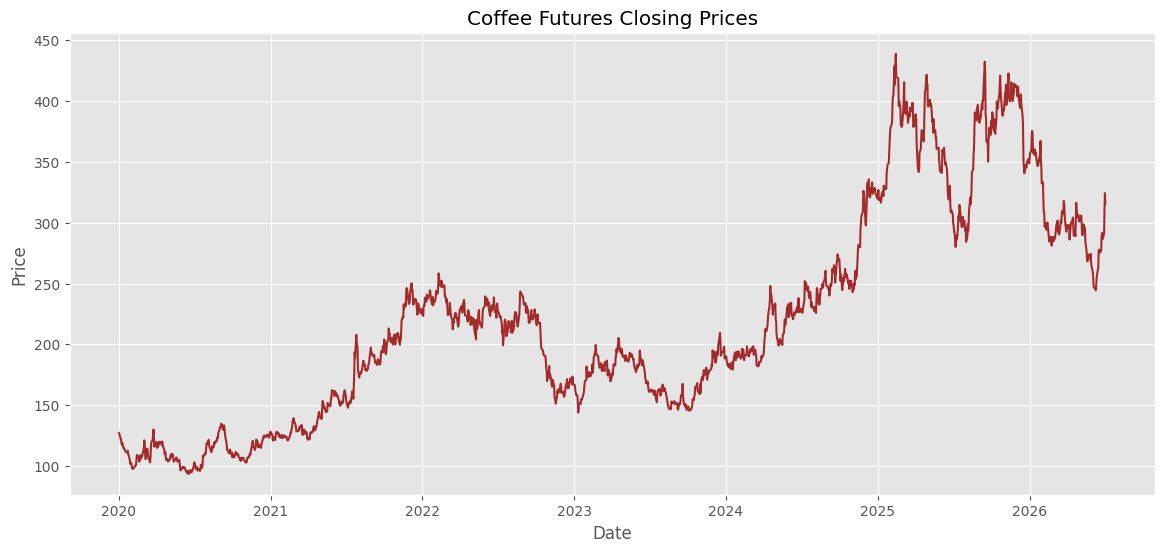

In [40]:
plt.figure(figsize=(14,6))

plt.plot(
    coffee.index,
    coffee["Close"],
    color="brown"
)

plt.title("Coffee Futures Closing Prices")

plt.xlabel("Date")

plt.ylabel("Price")

plt.show()

In [41]:
# Keep only the columns we need

coffee = coffee[['Open', 'High', 'Low', 'Close', 'Volume']]

# Remove missing values

coffee = coffee.dropna()

# Check again

coffee.info()

coffee.head()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1636 entries, 2020-01-02 to 2026-07-02
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Open, KC=F)    1636 non-null   float64
 1   (High, KC=F)    1636 non-null   float64
 2   (Low, KC=F)     1636 non-null   float64
 3   (Close, KC=F)   1636 non-null   float64
 4   (Volume, KC=F)  1636 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 76.7 KB


Price,Open,High,Low,Close,Volume
Ticker,KC=F,KC=F,KC=F,KC=F,KC=F
Date,,,,,
2020-01-02,129.550003,130.949997,126.500000,127.099998,21506
2020-01-03,127.199997,128.449997,125.449997,126.349998,16566
2020-01-06,126.250000,126.550003,121.550003,122.150002,24428
2020-01-07,122.599998,123.400002,119.849998,122.400002,21308
2020-01-08,122.500000,123.050003,118.250000,119.150002,23061


In [42]:
# Daily Percentage Returns

coffee["Daily Return"] = coffee["Close"].pct_change()

coffee.head()

Price,Open,High,Low,Close,Volume,Daily Return
Ticker,KC=F,KC=F,KC=F,KC=F,KC=F,
Date,,,,,,
2020-01-02,129.550003,130.949997,126.500000,127.099998,21506,NaN
2020-01-03,127.199997,128.449997,125.449997,126.349998,16566,-0.005901
2020-01-06,126.250000,126.550003,121.550003,122.150002,24428,-0.033241
2020-01-07,122.599998,123.400002,119.849998,122.400002,21308,0.002047
2020-01-08,122.500000,123.050003,118.250000,119.150002,23061,-0.026552


In [43]:
coffee = coffee.dropna()

coffee.head()

Price,Open,High,Low,Close,Volume,Daily Return
Ticker,KC=F,KC=F,KC=F,KC=F,KC=F,
Date,,,,,,
2020-01-03,127.199997,128.449997,125.449997,126.349998,16566,-0.005901
2020-01-06,126.250000,126.550003,121.550003,122.150002,24428,-0.033241
2020-01-07,122.599998,123.400002,119.849998,122.400002,21308,0.002047
2020-01-08,122.500000,123.050003,118.250000,119.150002,23061,-0.026552
2020-01-09,118.699997,120.349998,117.000000,117.349998,24637,-0.015107


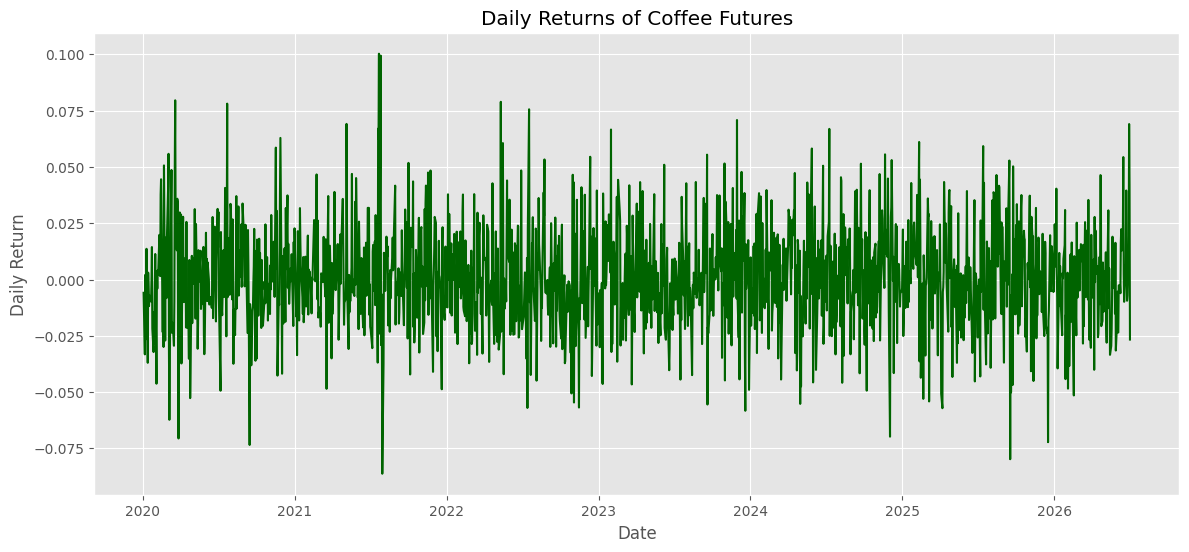

In [44]:
plt.figure(figsize=(14,6))

plt.plot(
    coffee.index,
    coffee["Daily Return"],
    color="darkgreen"
)

plt.title("Daily Returns of Coffee Futures")

plt.xlabel("Date")

plt.ylabel("Daily Return")

plt.show()

In [45]:
print("Mean Daily Return :", coffee["Daily Return"].mean())

print("Standard Deviation :", coffee["Daily Return"].std())

print("Maximum Return :", coffee["Daily Return"].max())

print("Minimum Return :", coffee["Daily Return"].min())

Mean Daily Return : 0.0008183726441305064
Standard Deviation : 0.02292325150376192
Maximum Return : 0.1002840562300249
Minimum Return : -0.08625952645415869


Coffee Futures show moderate-to-high daily volatility (2.29%), indicating noticeable price fluctuations. This level of volatility highlights why hedging and risk management are important in commodity markets.

In [46]:
# ============================================
# Rolling Volatility (30-Day)
# ============================================

coffee["Rolling Volatility"] = (
    coffee["Daily Return"]
    .rolling(window=30)
    .std()
)

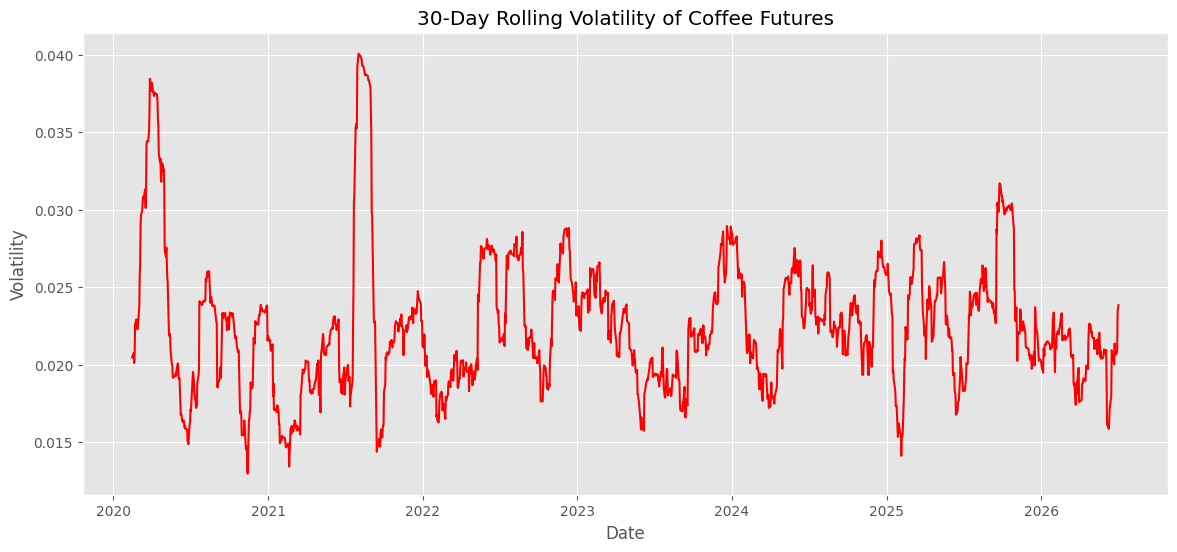

In [47]:
plt.figure(figsize=(14,6))

plt.plot(
    coffee.index,
    coffee["Rolling Volatility"],
    color="red",
    linewidth=1.5
)

plt.title("30-Day Rolling Volatility of Coffee Futures")

plt.xlabel("Date")

plt.ylabel("Volatility")

plt.grid(True)

plt.show()

In [48]:
# ============================================
# Annualized Volatility
# ============================================

annual_volatility = (
    coffee["Daily Return"].std()
    * np.sqrt(252)
)

print(f"Annualized Volatility: {annual_volatility:.2%}")

Annualized Volatility: 36.39%


In [49]:
print("\n===== VOLATILITY REPORT =====")

print(f"Daily Volatility      : {coffee['Daily Return'].std():.2%}")

print(f"Annualized Volatility : {annual_volatility:.2%}")

if annual_volatility < 0.15:
    print("Risk Level : LOW")

elif annual_volatility < 0.30:
    print("Risk Level : MODERATE")

else:
    print("Risk Level : HIGH")


===== VOLATILITY REPORT =====
Daily Volatility      : 2.29%
Annualized Volatility : 36.39%
Risk Level : HIGH


In [50]:
# ============================================
# Annualized Return
# ============================================

annual_return = coffee["Daily Return"].mean() * 252

print(f"Annualized Return: {annual_return:.2%}")

Annualized Return: 20.62%


In [51]:
# ============================================
# Sharpe Ratio
# ============================================

risk_free_rate = 0.04

sharpe_ratio = (
    annual_return - risk_free_rate
) / annual_volatility

print(f"Sharpe Ratio: {sharpe_ratio:.2f}")

Sharpe Ratio: 0.46


In [52]:
print("\n===== SHARPE RATIO REPORT =====")

print(f"Annual Return      : {annual_return:.2%}")
print(f"Risk Free Rate     : {risk_free_rate:.2%}")
print(f"Sharpe Ratio       : {sharpe_ratio:.2f}")

if sharpe_ratio >= 2:
    print("Performance : Excellent")

elif sharpe_ratio >= 1:
    print("Performance : Good")

elif sharpe_ratio >= 0:
    print("Performance : Acceptable")

else:
    print("Performance : Poor")


===== SHARPE RATIO REPORT =====
Annual Return      : 20.62%
Risk Free Rate     : 4.00%
Sharpe Ratio       : 0.46
Performance : Acceptable


In [53]:
# ============================================
# Maximum Drawdown
# ============================================

coffee["Cumulative Return"] = (
    1 + coffee["Daily Return"]
).cumprod()

coffee["Running Maximum"] = (
    coffee["Cumulative Return"]
).cummax()

coffee["Drawdown"] = (
    coffee["Cumulative Return"]
    - coffee["Running Maximum"]
) / coffee["Running Maximum"]

max_drawdown = coffee["Drawdown"].min()

print(f"Maximum Drawdown: {max_drawdown:.2%}")

Maximum Drawdown: -44.32%


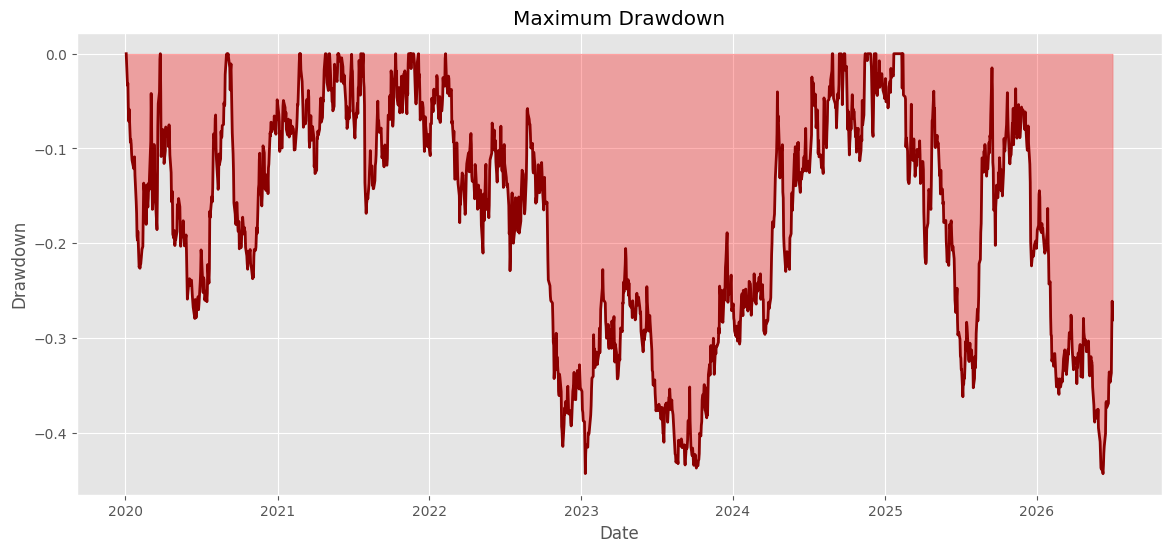

In [54]:
plt.figure(figsize=(14,6))

plt.plot(
    coffee.index,
    coffee["Drawdown"],
    color="darkred",
    linewidth=2
)

plt.fill_between(
    coffee.index,
    coffee["Drawdown"],
    0,
    color="red",
    alpha=0.3
)

plt.title("Maximum Drawdown")

plt.xlabel("Date")

plt.ylabel("Drawdown")

plt.grid(True)

plt.show()

In [55]:
print("\n===== DRAWDOWN REPORT =====")

print(f"Maximum Drawdown : {max_drawdown:.2%}")

if max_drawdown > -0.10:
    print("Drawdown Risk : LOW")

elif max_drawdown > -0.20:
    print("Drawdown Risk : MODERATE")

else:
    print("Drawdown Risk : HIGH")


===== DRAWDOWN REPORT =====
Maximum Drawdown : -44.32%
Drawdown Risk : HIGH


In [56]:
# ============================================
# Value at Risk (95%)
# ============================================

confidence_level = 0.95

var_95 = np.percentile(
    coffee["Daily Return"],
    (1 - confidence_level) * 100
)

print(f"95% Daily VaR : {var_95:.2%}")

95% Daily VaR : -3.61%


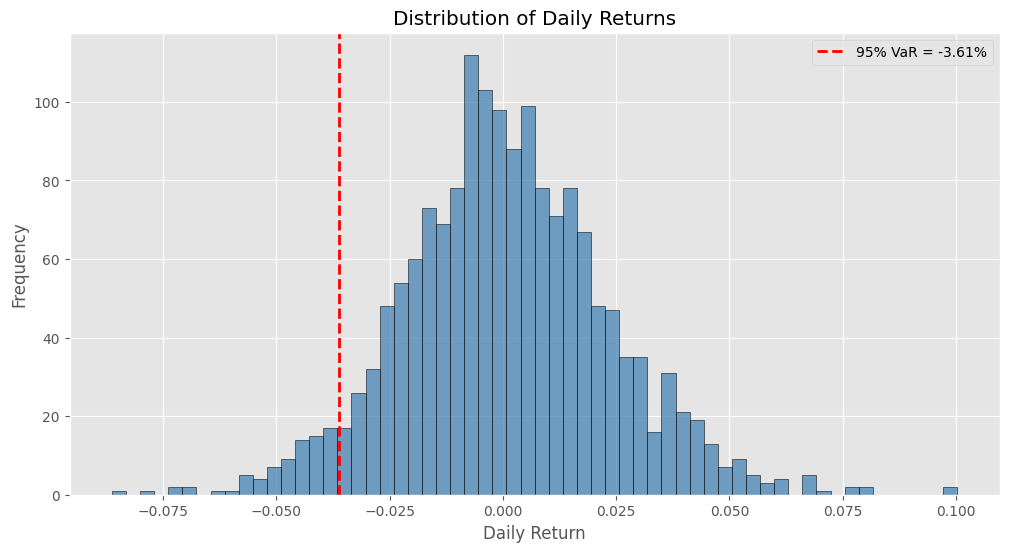

In [57]:
plt.figure(figsize=(12,6))

plt.hist(
    coffee["Daily Return"],
    bins=60,
    alpha=0.75,
    color="steelblue",
    edgecolor="black"
)

plt.axvline(
    var_95,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"95% VaR = {var_95:.2%}"
)

plt.title("Distribution of Daily Returns")

plt.xlabel("Daily Return")

plt.ylabel("Frequency")

plt.legend()

plt.grid(True)

plt.show()

In [58]:
print("\n===== VALUE AT RISK REPORT =====")

print(f"95% Daily VaR : {var_95:.2%}")

print(
    f"There is a 5% probability that daily losses "
    f"will exceed {abs(var_95):.2%}."
)


===== VALUE AT RISK REPORT =====
95% Daily VaR : -3.61%
There is a 5% probability that daily losses will exceed 3.61%.


In [60]:
# ============================================
# Parameters for Monte Carlo Simulation
# ============================================

current_price = coffee["Close"].iloc[-1]

mu = coffee["Daily Return"].mean()

sigma = coffee["Daily Return"].std()

print(f"Current Coffee Price : {current_price:.2f}")

print(f"Mean Daily Return    : {mu:.6f}")

print(f"Daily Volatility     : {sigma:.6f}")

TypeError: unsupported format string passed to Series.__format__

In [61]:
current_price = coffee["Close"].iloc[-1]

print(current_price)

print(type(current_price))

Ticker
KC=F    315.649994
Name: 2026-07-02 00:00:00, dtype: float64
<class 'pandas.core.series.Series'>


In [62]:
print(current_price)

print(type(current_price))

Ticker
KC=F    315.649994
Name: 2026-07-02 00:00:00, dtype: float64
<class 'pandas.core.series.Series'>


In [63]:
coffee.columns

MultiIndex([(              'Open', 'KC=F'),
            (              'High', 'KC=F'),
            (               'Low', 'KC=F'),
            (             'Close', 'KC=F'),
            (            'Volume', 'KC=F'),
            (      'Daily Return',     ''),
            ('Rolling Volatility',     ''),
            ( 'Cumulative Return',     ''),
            (   'Running Maximum',     ''),
            (          'Drawdown',     '')],
           names=['Price', 'Ticker'])

In [64]:
coffee.columns = [
    col[0] if col[1] == "" else col[0]
    for col in coffee.columns
]

print(coffee.columns)

Index(['Open', 'High', 'Low', 'Close', 'Volume', 'Daily Return',
       'Rolling Volatility', 'Cumulative Return', 'Running Maximum',
       'Drawdown'],
      dtype='object')


In [65]:
current_price = coffee["Close"].iloc[-1]

print(current_price)

print(type(current_price))

315.6499938964844
<class 'numpy.float64'>


In [66]:
# ============================================
# Parameters for Monte Carlo Simulation
# ============================================

current_price = coffee["Close"].iloc[-1]

mu = coffee["Daily Return"].mean()

sigma = coffee["Daily Return"].std()

print(f"Current Coffee Price : {current_price:.2f}")

print(f"Mean Daily Return    : {mu:.6f}")

print(f"Daily Volatility     : {sigma:.6f}")

Current Coffee Price : 315.65
Mean Daily Return    : 0.000818
Daily Volatility     : 0.022923


In [68]:
# ============================================
# Simulation Settings
# ============================================

num_simulations = 1000

forecast_days = 252

simulated_prices = np.zeros(
    (forecast_days, num_simulations)
)


In [69]:
# First day price

simulated_prices[0] = current_price

In [71]:
# ============================================
# Monte Carlo Price Simulation
# ============================================

for simulation in range(num_simulations):

    for day in range(1, forecast_days):

        random_return = np.random.normal(
            loc=mu,
            scale=sigma
        )

        simulated_prices[day, simulation] = (
            simulated_prices[day - 1, simulation]
            * (1 + random_return)
        )

print("Monte Carlo Simulation Completed Successfully ")

Monte Carlo Simulation Completed Successfully 


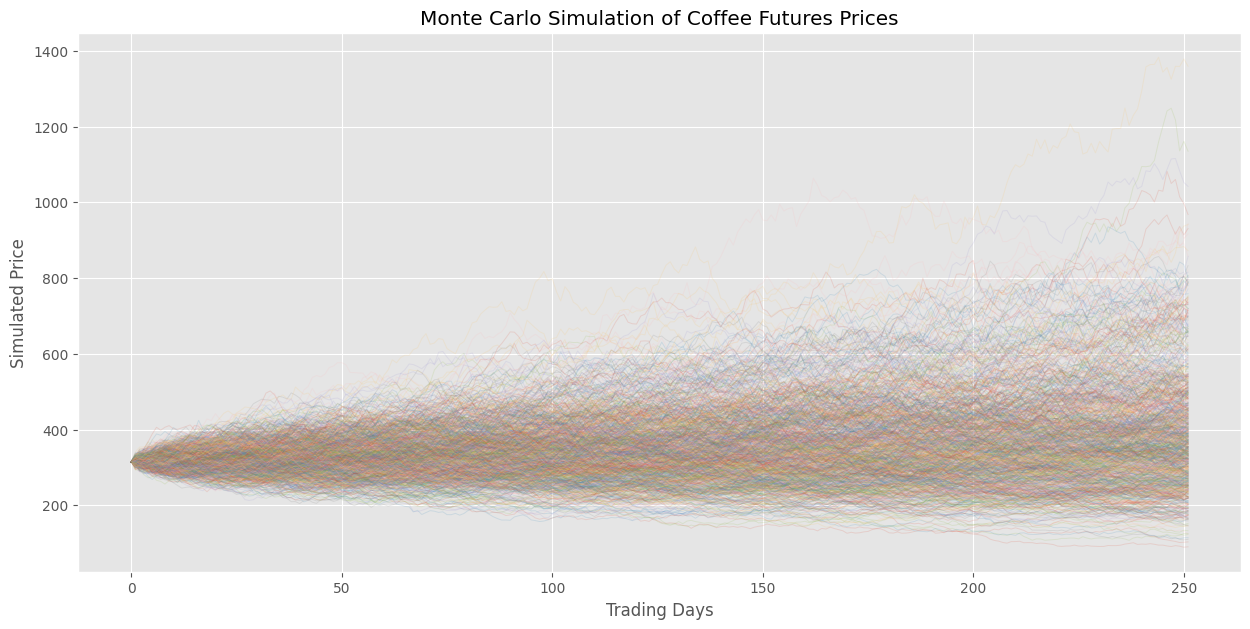

In [72]:
# ============================================
# Plot Monte Carlo Simulation
# ============================================

plt.figure(figsize=(15,7))

plt.plot(
    simulated_prices,
    linewidth=0.7,
    alpha=0.15
)

plt.title("Monte Carlo Simulation of Coffee Futures Prices")

plt.xlabel("Trading Days")

plt.ylabel("Simulated Price")

plt.grid(True)

plt.show()

In [73]:
# ============================================
# Confidence Intervals (Monte Carlo)
# ============================================

final_prices = simulated_prices[-1]

lower_bound = np.percentile(final_prices, 5)
upper_bound = np.percentile(final_prices, 95)
median_price = np.median(final_prices)

print(f"Current Price: {current_price:.2f}")
print(f"Median Forecast Price: {median_price:.2f}")
print(f"5% Worst Case: {lower_bound:.2f}")
print(f"95% Best Case: {upper_bound:.2f}")

Current Price: 315.65
Median Forecast Price: 367.57
5% Worst Case: 199.23
95% Best Case: 704.40
